# BioSentinel India: Biodiversity and Data Analytics

This notebook implements the Person 1 responsibilities: species richness, species frequency, taxonomic composition, diversity/evenness, Grid x Year aggregation, and indicator validation.

**Interpretation:** `occurrences` are GBIF observation records, not animal abundance. Diversity values therefore describe the distribution of records among species and remain sensitive to sampling effort.

## 1. Setup and analysis parameters

The primary comparison window is 2015-2024. Years outside this window remain in the temporal overview, but 2025-2026 are excluded from comparable indicators because coverage is incomplete.

In [ ]:
from pathlib import Path
import gc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing data/ and notebooks/.")

PROJECT_ROOT = find_project_root()
INPUT_PATH = PROJECT_ROOT / "data" / "processed" / "gbif_terrestrial_species_year_grid.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "analytics"

ANALYSIS_START_YEAR = 2015
ANALYSIS_END_YEAR = 2024
MIN_OCCURRENCES_FOR_COMPARISON = 25
INDIA_LONGITUDE_RANGE = (68, 98)
INDIA_LATITUDE_RANGE = (6, 38)

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Processed data not found at {INPUT_PATH}. Run notebooks/01_gbif_audit.ipynb first."
    )

print("Project root:", PROJECT_ROOT)
print("Input:", INPUT_PATH)
print(f"Primary analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")

Project root: C:\Users\dshar\Desktop\dhruv\Biosential_India
Input: C:\Users\dshar\Desktop\dhruv\Biosential_India\data\processed\gbif_terrestrial_species_year_grid.parquet
Primary analysis period: 2015-2024


## 2. Load and validate the processed cube

In [ ]:
REQUIRED_COLUMNS = [
    "kingdom", "class", "order", "family", "genus",
    "species", "specieskey", "year", "eqdcellcode", "occurrences"
]
CATEGORICAL_COLUMNS = [
    "kingdom", "class", "order", "family", "genus",
    "species", "specieskey", "eqdcellcode"
]

parquet_file = pq.ParquetFile(INPUT_PATH)
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(parquet_file.schema.names))
if missing_columns:
    raise ValueError(f"Processed dataset is missing required columns: {missing_columns}")

table = pq.read_table(INPUT_PATH, columns=REQUIRED_COLUMNS)
data = table.to_pandas(categories=CATEGORICAL_COLUMNS)
del table
gc.collect()

print(f"Rows: {len(data):,}")
print(f"Underlying GBIF records: {data['occurrences'].sum():,}")
print(f"Species: {data['specieskey'].nunique():,}")
print(f"Grid cells: {data['eqdcellcode'].nunique():,}")
print(f"Years: {data['year'].min()}-{data['year'].max()}")
display(data.head())

Rows: 3,664,155
Underlying GBIF records: 62,120,210
Species: 13,065
Grid cells: 8,434
Years: 1820-2026


,kingdom,class,order,family,genus,species,specieskey,year,eqdcellcode,occurrences
0,Animalia,Insecta,Lepidoptera,NaN,NaN,Tarucus nara,FLBS2,2025,E083N19DB,2
1,Animalia,Insecta,Lepidoptera,NaN,NaN,Tarucus nara,FLBS2,2024,E085N20DA,2
2,Animalia,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea coromanda,CPZZ7,2019,E071N21CA,1
3,Animalia,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea intermedia,CPZZN,2019,E071N21CA,1
4,Animalia,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea cinerea,GCHS,2019,E071N21CA,1


In [ ]:
critical_columns = ["specieskey", "year", "eqdcellcode", "occurrences"]
null_critical_rows = int(data[critical_columns].isna().any(axis=1).sum())
non_positive_occurrence_rows = int((data["occurrences"] <= 0).sum())
duplicate_group_rows = int(
    data.duplicated(["specieskey", "year", "eqdcellcode"], keep=False).sum()
)
name_variants = data.groupby("specieskey", observed=True)["species"].nunique()
species_keys_with_multiple_names = int((name_variants > 1).sum())

grid_parts = data["eqdcellcode"].astype("string").str.extract(
    r"^(?P<east_west>[EW])(?P<longitude>\d{3})(?P<north_south>[NS])(?P<latitude>\d{2})[A-D]{2}$"
)
longitude = pd.to_numeric(grid_parts["longitude"], errors="coerce")
latitude = pd.to_numeric(grid_parts["latitude"], errors="coerce")
longitude = longitude.where(grid_parts["east_west"] == "E", -longitude)
latitude = latitude.where(grid_parts["north_south"] == "N", -latitude)

data["plausible_india_cell"] = (
    longitude.between(*INDIA_LONGITUDE_RANGE)
    & latitude.between(*INDIA_LATITUDE_RANGE)
)
questionable_grid_rows = int((~data["plausible_india_cell"]).sum())
questionable_grid_cells = int(
    data.loc[~data["plausible_india_cell"], "eqdcellcode"].nunique()
)

qc_summary = pd.DataFrame({
    "check": [
        "Rows with a missing critical field",
        "Rows with non-positive occurrences",
        "Rows in duplicate species-year-grid groups",
        "Species keys linked to multiple names",
        "Rows outside the coarse India bounding box",
        "Grid cells outside the coarse India bounding box",
    ],
    "value": [
        null_critical_rows, non_positive_occurrence_rows, duplicate_group_rows,
        species_keys_with_multiple_names, questionable_grid_rows, questionable_grid_cells,
    ],
})
display(qc_summary)

if questionable_grid_cells:
    print("Example questionable grid codes:")
    display(
        data.loc[~data["plausible_india_cell"], ["eqdcellcode", "occurrences"]]
        .groupby("eqdcellcode", observed=True)["occurrences"].sum()
        .sort_values(ascending=False).head(15).to_frame()
    )

,check,value
0,Rows with a missing critical field,0
1,Rows with non-positive occurrences,0
2,Rows in duplicate species-year-grid groups,0
3,Species keys linked to multiple names,0
4,Rows outside the coarse India bounding box,1495
5,Grid cells outside the coarse India bounding box,1389


Example questionable grid codes:


,occurrences
eqdcellcode,
E075N01AB,4
E074S00DB,3
E072N05BD,3
E075N01AC,3
E072N00BA,3
E066N20DA,3
E076N04AC,3
E082N00CA,3
E072S02AB,2


## 3. Temporal coverage and primary analysis subset

The all-year overview diagnoses collection effort. Primary biodiversity indicators use only 2015-2024 and plausible India grid codes. The bounding-box test is deliberately coarse: it catches obvious coordinate-country conflicts but is not a substitute for an India boundary polygon.

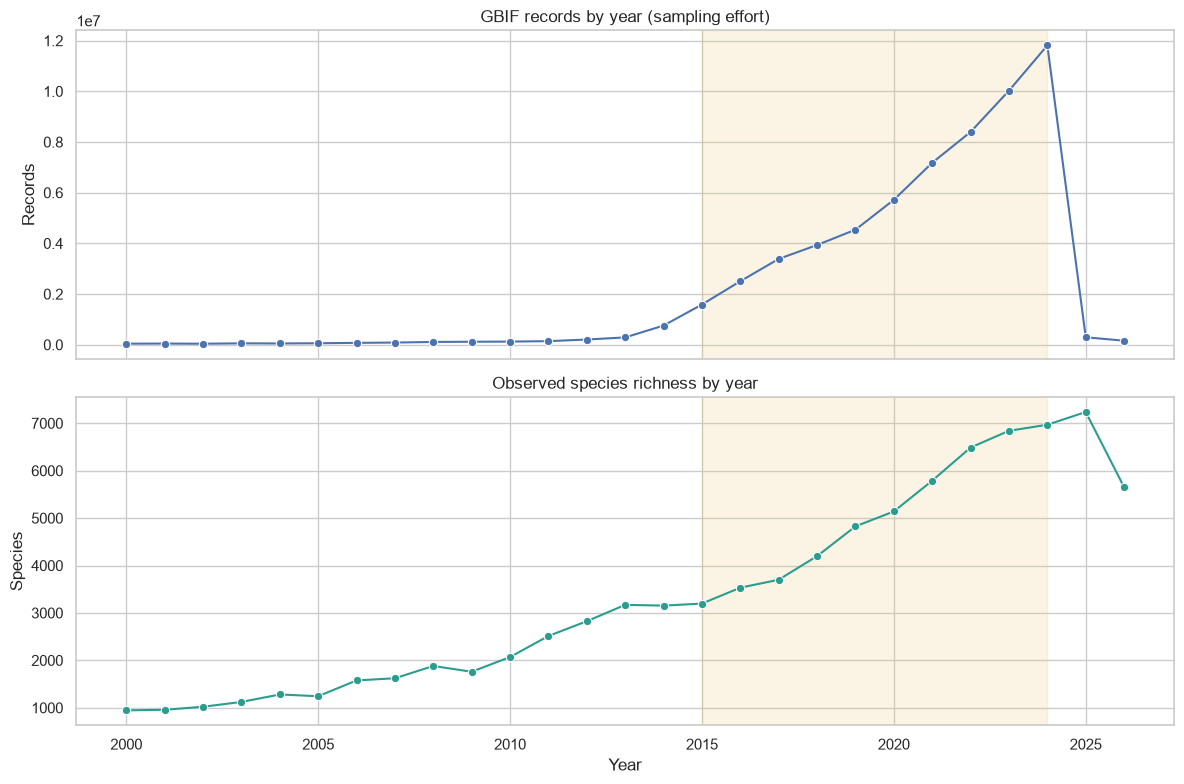

,year,total_occurrences,species_richness,occupied_grids,cube_rows
159,2012,205367,2825,1672,58919
160,2013,288131,3170,1810,73378
161,2014,755610,3154,2191,112572
162,2015,1585704,3197,2479,142919
163,2016,2505770,3532,2705,171905
164,2017,3385548,3700,3115,204644
165,2018,3934826,4198,3317,229205
166,2019,4538443,4825,3744,259279
167,2020,5717371,5140,3563,272165
168,2021,7180361,5789,4002,319664


In [ ]:
annual_overview = (
    data.groupby("year", observed=True)
    .agg(
        total_occurrences=("occurrences", "sum"),
        species_richness=("specieskey", "nunique"),
        occupied_grids=("eqdcellcode", "nunique"),
        cube_rows=("specieskey", "size"),
    )
    .reset_index()
    .sort_values("year")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
recent_overview = annual_overview[annual_overview["year"] >= 2000]
sns.lineplot(recent_overview, x="year", y="total_occurrences", marker="o", ax=axes[0])
sns.lineplot(recent_overview, x="year", y="species_richness", marker="o", color="#2a9d8f", ax=axes[1])
axes[0].set(title="GBIF records by year (sampling effort)", ylabel="Records")
axes[1].set(title="Observed species richness by year", ylabel="Species", xlabel="Year")
for ax in axes:
    ax.axvspan(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, color="#e9c46a", alpha=0.18)
plt.tight_layout()
plt.show()

display(annual_overview.tail(15))

In [ ]:
analysis_mask = (
    data["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    & data["plausible_india_cell"]
    & data["occurrences"].gt(0)
    & data["specieskey"].notna()
)
analysis_columns = [
    "class", "order", "family", "genus", "species",
    "specieskey", "year", "eqdcellcode", "occurrences"
]
analysis = data.loc[analysis_mask, analysis_columns].copy()
for column in analysis.select_dtypes(include="category").columns:
    analysis[column] = analysis[column].cat.remove_unused_categories()

print(f"Primary rows: {len(analysis):,}")
print(f"Primary GBIF records: {analysis['occurrences'].sum():,}")
print(f"Primary species: {analysis['specieskey'].nunique():,}")
print(f"Primary grid cells: {analysis['eqdcellcode'].nunique():,}")
print(f"Excluded questionable-grid rows in period: {(data['year'].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR) & ~data['plausible_india_cell']).sum():,}")

Primary rows: 2,768,208
Primary GBIF records: 59,081,332
Primary species: 11,474
Primary grid cells: 6,625
Excluded questionable-grid rows in period: 1,293


## 4. Species richness

Richness is the number of distinct `specieskey` values observed. It is shown nationally by year and spatially by grid; it is not corrected for unequal sampling effort.

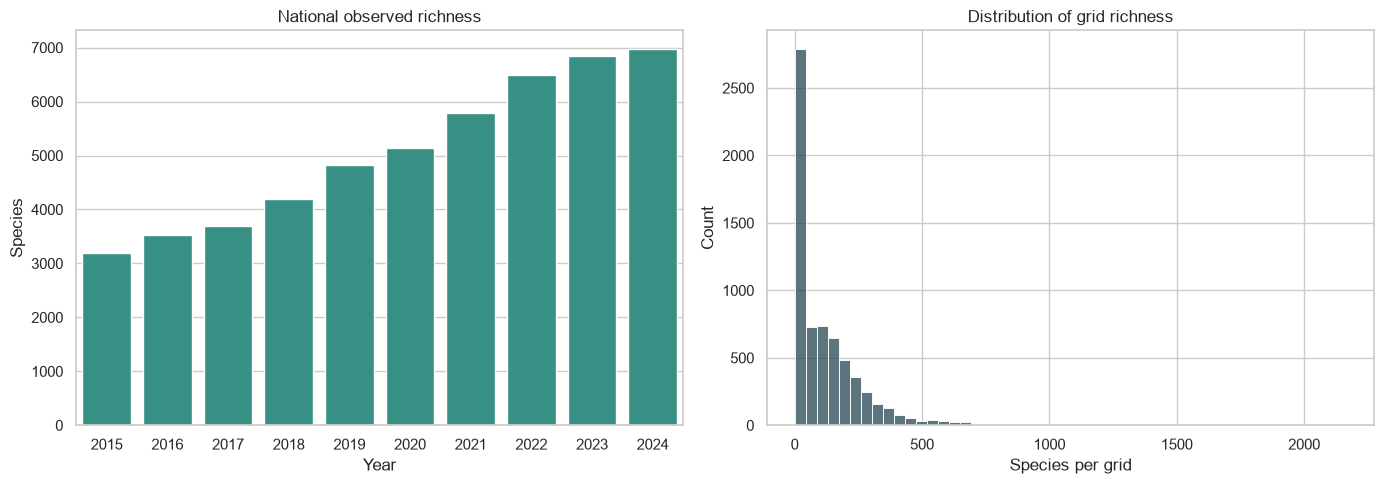

,year,species_richness,total_occurrences,occupied_grids
0,2015,3195,1585689,2465
1,2016,3530,2505748,2683
2,2017,3697,3385533,3100
3,2018,4198,3934813,3304
4,2019,4825,4538386,3687
5,2020,5139,5717323,3515
6,2021,5789,7180201,3843
7,2022,6488,8396584,4290
8,2023,6840,10025093,4716
9,2024,6969,11811962,4475


,eqdcellcode,species_richness,total_occurrences,observed_years
231,E092N24CB,2166,52346,10
227,E088N27CD,1966,49401,10
345,E088N27DA,1847,47649,10
277,E077N12BA,1581,2136924,10
113,E072N19DD,1501,733769,10
90,E077N09AC,1324,161745,10
326,E077N13DC,1309,1443286,10
1780,E076N10CD,1249,423961,10
131,E080N12AA,1229,666660,10
575,E088N27DC,1218,155449,10


In [ ]:
annual_richness = (
    analysis.groupby("year", observed=True)
    .agg(
        species_richness=("specieskey", "nunique"),
        total_occurrences=("occurrences", "sum"),
        occupied_grids=("eqdcellcode", "nunique"),
    )
    .reset_index()
)

grid_richness = (
    analysis.groupby("eqdcellcode", observed=True)
    .agg(
        species_richness=("specieskey", "nunique"),
        total_occurrences=("occurrences", "sum"),
        observed_years=("year", "nunique"),
    )
    .reset_index()
    .sort_values("species_richness", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(annual_richness, x="year", y="species_richness", color="#2a9d8f", ax=axes[0])
sns.histplot(grid_richness, x="species_richness", bins=50, color="#264653", ax=axes[1])
axes[0].set(title="National observed richness", ylabel="Species", xlabel="Year")
axes[1].set(title="Distribution of grid richness", xlabel="Species per grid")
plt.tight_layout()
plt.show()

display(annual_richness)
display(grid_richness.head(20))

## 5. Species frequency

Frequency is reported in complementary ways: number of GBIF records, occupied grids, detected years, and occupied Grid x Year units. This avoids treating record count alone as ecological frequency.

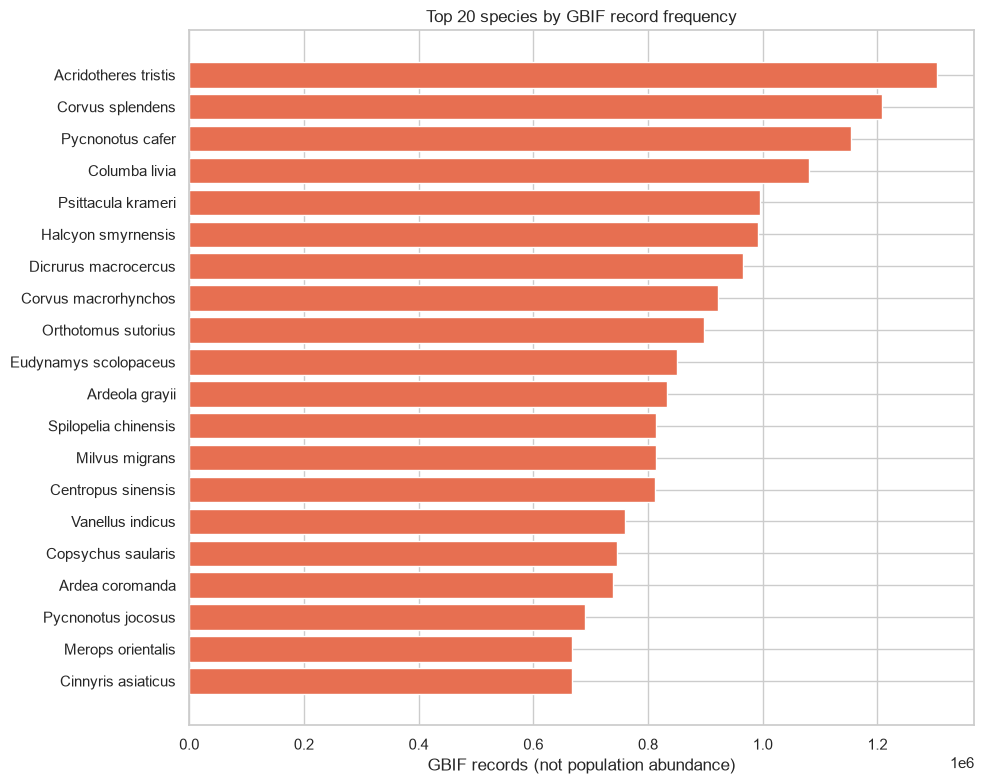

,specieskey,total_occurrences,occupied_grids,observed_years,occupied_grid_years,species,class,order,family,genus,relative_observation_pct,grid_occupancy_pct,temporal_frequency_pct,grid_year_occupancy_pct
1203,9KHT,1303273,3952,10,21720,Acridotheres tristis,Aves,Passeriformes,Sturnidae,Acridotheres,2.2059,59.6528,100.0000,60.2029
382,YNJJ,1207803,3825,10,20045,Corvus splendens,Aves,Passeriformes,Corvidae,Corvus,2.0443,57.7358,100.0000,55.5602
685,4QMM8,1153096,3950,10,21677,Pycnonotus cafer,Aves,Passeriformes,Pycnonotidae,Pycnonotus,1.9517,59.6226,100.0000,60.0837
97,XBFW,1080145,3926,10,20127,Columba livia,Aves,Columbiformes,Columbidae,Columba,1.8282,59.2604,100.0000,55.7875
513,4PKCM,994650,3594,10,18496,Psittacula krameri,Aves,Psittaciformes,Psittaculidae,Psittacula,1.6835,54.2491,100.0000,51.2667
248,6KY3J,991183,3827,10,20436,Halcyon smyrnensis,Aves,Coraciiformes,Alcedinidae,Halcyon,1.6777,57.7660,100.0000,56.6439
151,6D5S3,965967,3893,10,21120,Dicrurus macrocercus,Aves,Passeriformes,Dicruridae,Dicrurus,1.6350,58.7623,100.0000,58.5398
384,YNJ4,921406,3344,10,16418,Corvus macrorhynchos,Aves,Passeriformes,Corvidae,Corvus,1.5596,50.4755,100.0000,45.5070
461,6SXXL,897721,3406,10,16409,Orthotomus sutorius,Aves,Passeriformes,Cisticolidae,Orthotomus,1.5195,51.4113,100.0000,45.4820
178,3C39Q,851094,3419,10,16253,Eudynamys scolopaceus,Aves,Cuculiformes,Cuculidae,Eudynamys,1.4405,51.6075,100.0000,45.0496


In [ ]:
taxonomy_lookup = (
    analysis.sort_values("occurrences", ascending=False)
    .drop_duplicates("specieskey")
    [["specieskey", "species", "class", "order", "family", "genus"]]
)

species_frequency = (
    analysis.groupby("specieskey", observed=True)
    .agg(
        total_occurrences=("occurrences", "sum"),
        occupied_grids=("eqdcellcode", "nunique"),
        observed_years=("year", "nunique"),
        occupied_grid_years=("specieskey", "size"),
    )
    .reset_index()
    .merge(taxonomy_lookup, on="specieskey", how="left", validate="one_to_one")
)
eligible_grid_years = analysis[["eqdcellcode", "year"]].drop_duplicates().shape[0]
species_frequency["relative_observation_pct"] = (
    species_frequency["total_occurrences"] / species_frequency["total_occurrences"].sum() * 100
)
species_frequency["grid_occupancy_pct"] = (
    species_frequency["occupied_grids"] / analysis["eqdcellcode"].nunique() * 100
)
species_frequency["temporal_frequency_pct"] = (
    species_frequency["observed_years"] / (ANALYSIS_END_YEAR - ANALYSIS_START_YEAR + 1) * 100
)
species_frequency["grid_year_occupancy_pct"] = (
    species_frequency["occupied_grid_years"] / eligible_grid_years * 100
)
species_frequency = species_frequency.sort_values("total_occurrences", ascending=False)

top_species = species_frequency.head(20).sort_values("total_occurrences")
plt.figure(figsize=(10, 8))
plt.barh(top_species["species"].astype(str), top_species["total_occurrences"], color="#e76f51")
plt.title("Top 20 species by GBIF record frequency")
plt.xlabel("GBIF records (not population abundance)")
plt.tight_layout()
plt.show()

display(species_frequency.head(25))

## 6. Taxonomic composition

Composition includes both observation share and species-richness share. Observation share is strongly affected by taxon-specific reporting behaviour.

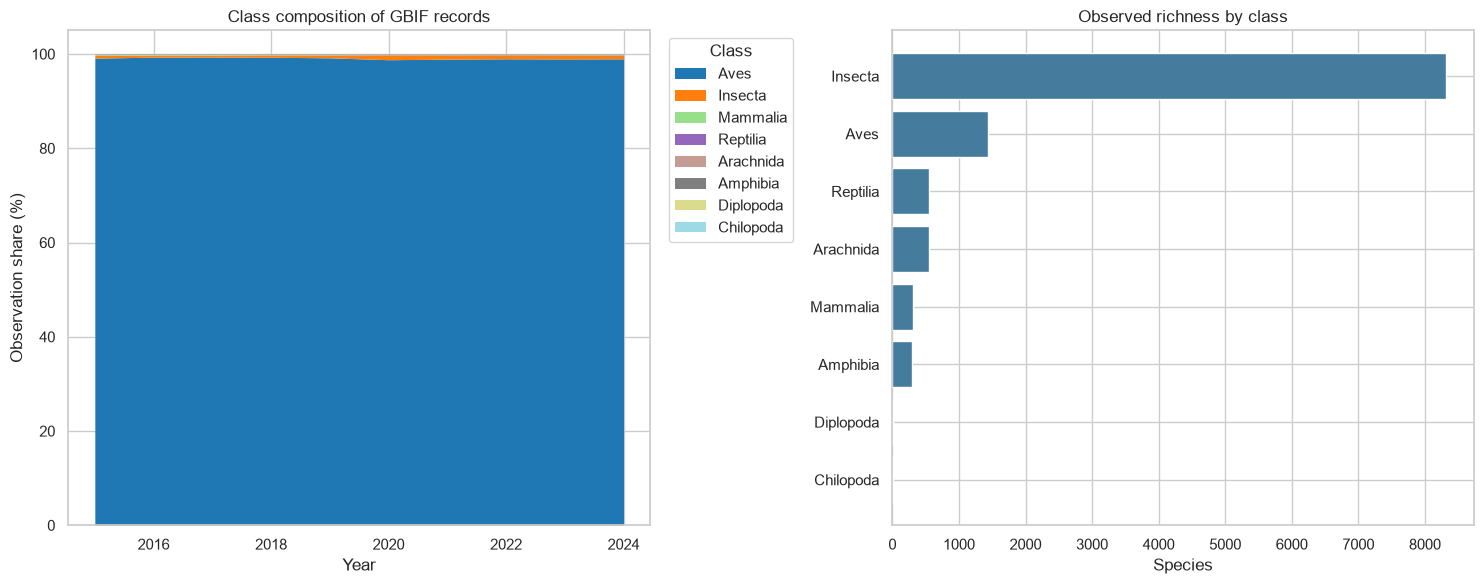

,rank,taxon,total_occurrences,species_richness,observation_share_pct,richness_share_pct
0,class,Aves,58506806,1429,99.0276,12.4542
1,class,Insecta,452869,8321,0.7665,72.5205
2,class,Mammalia,44792,307,0.0758,2.6756
3,class,Reptilia,34972,553,0.0592,4.8196
4,class,Arachnida,26629,546,0.0451,4.7586
5,class,Amphibia,13756,289,0.0233,2.5187
6,class,Diplopoda,1258,15,0.0021,0.1307
7,class,Chilopoda,250,14,0.0004,0.1220
8,order,Passeriformes,28461525,777,48.1735,6.7718
9,order,Pelecaniformes,4232285,35,7.1635,0.3050


In [ ]:
def summarize_composition(frame, rank):
    result = (
        frame.groupby(rank, observed=True, dropna=False)
        .agg(total_occurrences=("occurrences", "sum"), species_richness=("specieskey", "nunique"))
        .reset_index()
        .rename(columns={rank: "taxon"})
    )
    result.insert(0, "rank", rank)
    result["observation_share_pct"] = result["total_occurrences"] / result["total_occurrences"].sum() * 100
    result["richness_share_pct"] = result["species_richness"] / result["species_richness"].sum() * 100
    return result.sort_values("total_occurrences", ascending=False)

composition_tables = [summarize_composition(analysis, rank) for rank in ["class", "order", "family"]]
taxonomic_composition = pd.concat(composition_tables, ignore_index=True)
class_composition = composition_tables[0]

class_year_occurrences = (
    analysis.groupby(["year", "class"], observed=True)["occurrences"].sum()
    .unstack(fill_value=0)
)
class_year_share = class_year_occurrences.div(class_year_occurrences.sum(axis=1), axis=0) * 100
class_order = class_year_occurrences.sum().sort_values(ascending=False).index
class_year_share = class_year_share[class_order]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
class_year_share.plot.area(ax=axes[0], colormap="tab20", linewidth=0)
axes[0].set(title="Class composition of GBIF records", ylabel="Observation share (%)", xlabel="Year")
axes[0].legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
class_plot = class_composition.sort_values("species_richness", ascending=True)
axes[1].barh(class_plot["taxon"].astype(str), class_plot["species_richness"], color="#457b9d")
axes[1].set(title="Observed richness by class", xlabel="Species")
plt.tight_layout()
plt.show()

display(taxonomic_composition.groupby("rank", sort=False).head(15))

## 7. Grid x Year aggregation, diversity, and evenness

Species rows are re-aggregated before calculation, making this section robust if duplicate cube keys are introduced later. For each grid-year, species record proportions are used for Shannon, Simpson, and Pielou indicators.

In [ ]:
species_grid_year = (
    analysis.groupby(["eqdcellcode", "year", "specieskey"], observed=True, as_index=False)
    ["occurrences"].sum()
)
species_grid_year["group_total"] = (
    species_grid_year.groupby(["eqdcellcode", "year"], observed=True)["occurrences"].transform("sum")
)
species_grid_year["proportion"] = species_grid_year["occurrences"] / species_grid_year["group_total"]
species_grid_year["p_log_p"] = species_grid_year["proportion"] * np.log(species_grid_year["proportion"])
species_grid_year["p_squared"] = species_grid_year["proportion"].pow(2)

group_keys = ["eqdcellcode", "year"]
grid_year = (
    species_grid_year.groupby(group_keys, observed=True)
    .agg(
        total_occurrences=("occurrences", "sum"),
        species_richness=("specieskey", "size"),
        p_log_p_sum=("p_log_p", "sum"),
        p_squared_sum=("p_squared", "sum"),
    )
    .reset_index()
)
class_richness = (
    analysis.groupby(group_keys, observed=True)["class"].nunique().rename("class_richness").reset_index()
)
source_rows = (
    analysis.groupby(group_keys, observed=True).size().rename("source_cube_rows").reset_index()
)
grid_year = grid_year.merge(class_richness, on=group_keys, validate="one_to_one")
grid_year = grid_year.merge(source_rows, on=group_keys, validate="one_to_one")
grid_year["shannon_diversity"] = -grid_year.pop("p_log_p_sum")
grid_year["simpson_diversity"] = 1 - grid_year.pop("p_squared_sum")
grid_year["pielou_evenness"] = np.where(
    grid_year["species_richness"] > 1,
    grid_year["shannon_diversity"] / np.log(grid_year["species_richness"]),
    np.nan,
)
grid_year["simpson_diversity"] = grid_year["simpson_diversity"].clip(0, 1)
grid_year["pielou_evenness"] = grid_year["pielou_evenness"].clip(0, 1)
grid_year["sufficient_sampling"] = (
    grid_year["total_occurrences"].ge(MIN_OCCURRENCES_FOR_COMPARISON)
    & grid_year["species_richness"].ge(2)
)
grid_year["sampling_flag"] = np.where(
    grid_year["sufficient_sampling"], "usable_with_caution", "data_limited"
)
grid_year = grid_year.sort_values(group_keys).reset_index(drop=True)

print(f"Grid x Year rows: {len(grid_year):,}")
print(f"Rows meeting the sampling threshold: {grid_year['sufficient_sampling'].sum():,} ({grid_year['sufficient_sampling'].mean() * 100:.1f}%)")
display(grid_year.head(20))

Grid x Year rows: 36,078
Rows meeting the sampling threshold: 23,821 (66.0%)


,eqdcellcode,year,total_occurrences,species_richness,class_richness,source_cube_rows,shannon_diversity,simpson_diversity,pielou_evenness,sufficient_sampling,sampling_flag
0,E083N19DB,2023,13,13,1,13,2.5649,0.9231,1.0000,False,data_limited
1,E083N19DB,2024,184,119,7,119,4.5419,0.9852,0.9504,True,usable_with_caution
2,E085N20DA,2015,104,82,4,82,4.3411,0.9859,0.9851,True,usable_with_caution
3,E085N20DA,2016,248,102,1,102,4.4708,0.9870,0.9667,True,usable_with_caution
4,E085N20DA,2017,1875,174,1,174,4.6303,0.9868,0.8975,True,usable_with_caution
5,E085N20DA,2018,3273,194,3,194,4.6230,0.9868,0.8776,True,usable_with_caution
6,E085N20DA,2019,612,144,2,144,4.6618,0.9884,0.9380,True,usable_with_caution
7,E085N20DA,2020,1006,175,3,175,4.8222,0.9901,0.9337,True,usable_with_caution
8,E085N20DA,2021,1661,220,4,220,4.9090,0.9905,0.9101,True,usable_with_caution
9,E085N20DA,2022,1283,141,3,141,4.5942,0.9876,0.9283,True,usable_with_caution


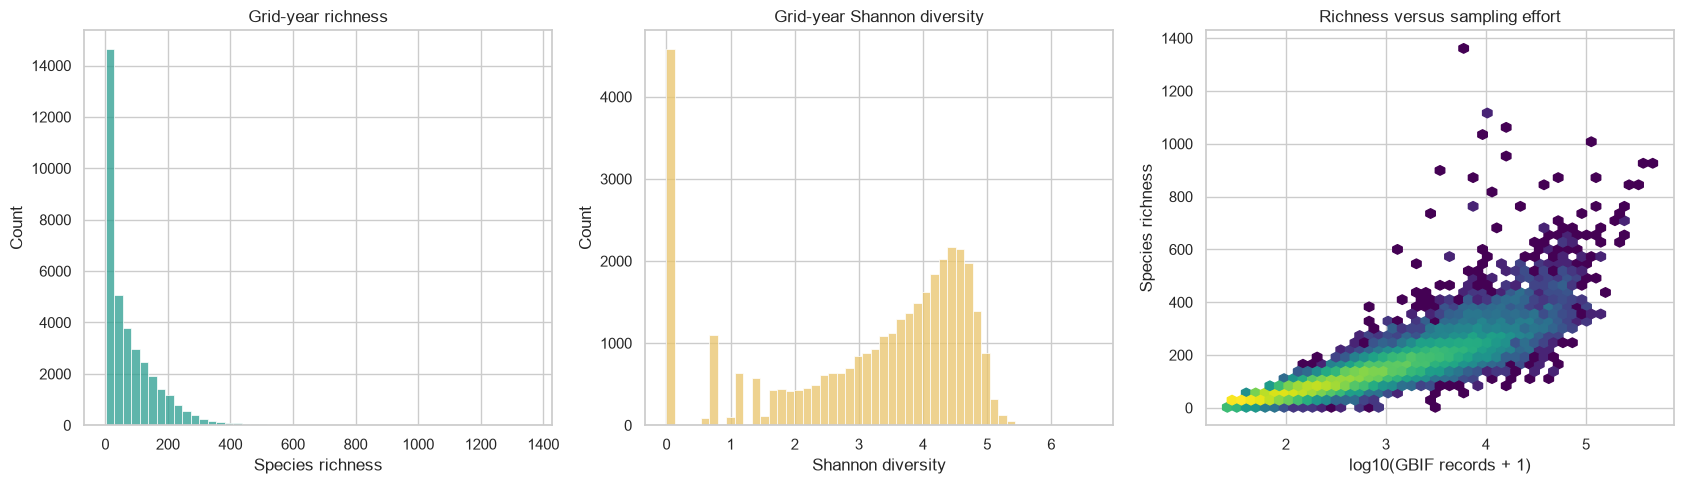

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(grid_year, x="species_richness", bins=50, ax=axes[0], color="#2a9d8f")
sns.histplot(grid_year, x="shannon_diversity", bins=50, ax=axes[1], color="#e9c46a")
usable = grid_year[grid_year["sufficient_sampling"]]
axes[2].hexbin(
    np.log10(usable["total_occurrences"] + 1),
    usable["species_richness"],
    gridsize=45, bins="log", cmap="viridis", mincnt=1,
)
axes[0].set(title="Grid-year richness", xlabel="Species richness")
axes[1].set(title="Grid-year Shannon diversity", xlabel="Shannon diversity")
axes[2].set(title="Richness versus sampling effort", xlabel="log10(GBIF records + 1)", ylabel="Species richness")
plt.tight_layout()
plt.show()

## 8. Indicator validation

Validation covers formula behaviour, bounds, source-total reconciliation, independent recalculation on sampled groups, effort correlation, and threshold sensitivity. It does not establish ecological ground truth; that requires an external standardized survey or checklist.

In [ ]:
def calculate_diversity(counts):
    counts = np.asarray(counts, dtype=float)
    proportions = counts / counts.sum()
    richness = len(counts)
    shannon = float(-(proportions * np.log(proportions)).sum())
    simpson = float(1 - np.square(proportions).sum())
    evenness = float(shannon / np.log(richness)) if richness > 1 else np.nan
    return richness, shannon, simpson, evenness

validation_records = []
def add_validation(check, passed, observed, severity="ERROR"):
    validation_records.append({
        "check": check,
        "status": "PASS" if bool(passed) else severity,
        "observed": observed,
    })

toy_richness, toy_shannon, toy_simpson, toy_evenness = calculate_diversity([1, 1, 1, 1])
add_validation("Equal-abundance toy richness is 4", toy_richness == 4, toy_richness)
add_validation("Equal-abundance toy Shannon is ln(4)", np.isclose(toy_shannon, np.log(4)), toy_shannon)
add_validation("Equal-abundance toy Simpson is 0.75", np.isclose(toy_simpson, 0.75), toy_simpson)
add_validation("Equal-abundance toy evenness is 1", np.isclose(toy_evenness, 1), toy_evenness)
add_validation("No missing critical input fields", null_critical_rows == 0, null_critical_rows)
add_validation("All occurrence counts are positive", non_positive_occurrence_rows == 0, non_positive_occurrence_rows)
add_validation("No duplicate species-year-grid input groups", duplicate_group_rows == 0, duplicate_group_rows)
add_validation("Shannon values are non-negative", (grid_year["shannon_diversity"] >= -1e-12).all(), grid_year["shannon_diversity"].min())
add_validation("Simpson values are within [0, 1]", grid_year["simpson_diversity"].between(0, 1).all(), f"{grid_year['simpson_diversity'].min():.6f} to {grid_year['simpson_diversity'].max():.6f}")
non_null_evenness = grid_year["pielou_evenness"].dropna()
add_validation("Pielou values are within [0, 1]", non_null_evenness.between(0, 1).all(), f"{non_null_evenness.min():.6f} to {non_null_evenness.max():.6f}")
add_validation("Grid-year totals reconcile with source", int(grid_year["total_occurrences"].sum()) == int(analysis["occurrences"].sum()), f"{grid_year['total_occurrences'].sum():,} vs {analysis['occurrences'].sum():,}")
questionable_primary_rows = int((~data.loc[analysis.index, "plausible_india_cell"]).sum())
add_validation("Primary analysis excludes questionable grid codes", questionable_primary_rows == 0, questionable_primary_rows)
add_validation("Source grid codes pass the coarse India screen", questionable_grid_cells == 0, questionable_grid_cells, severity="WARN")

sample_keys = grid_year.sample(min(25, len(grid_year)), random_state=42)[group_keys]
sample_species = species_grid_year.merge(sample_keys, on=group_keys, how="inner")
manual_rows = []
for (cell, year), group in sample_species.groupby(group_keys, observed=True):
    richness, shannon, simpson, evenness = calculate_diversity(group["occurrences"])
    manual_rows.append({
        "eqdcellcode": cell, "year": year, "manual_richness": richness,
        "manual_shannon": shannon, "manual_simpson": simpson, "manual_evenness": evenness,
    })
manual_check = pd.DataFrame(manual_rows).merge(grid_year, on=group_keys, validate="one_to_one")
manual_passed = (
    (manual_check["manual_richness"] == manual_check["species_richness"]).all()
    and np.allclose(manual_check["manual_shannon"], manual_check["shannon_diversity"])
    and np.allclose(manual_check["manual_simpson"], manual_check["simpson_diversity"])
    and np.allclose(manual_check["manual_evenness"], manual_check["pielou_evenness"], equal_nan=True)
)
add_validation("Independent sample recalculation matches vectorized indicators", manual_passed, f"{len(manual_check)} groups checked")

validation_results = pd.DataFrame(validation_records)
display(validation_results)

,check,status,observed
0,Equal-abundance toy richness is 4,PASS,4
1,Equal-abundance toy Shannon is ln(4),PASS,1.3863
2,Equal-abundance toy Simpson is 0.75,PASS,0.7500
3,Equal-abundance toy evenness is 1,PASS,1.0000
4,No missing critical input fields,PASS,0
5,All occurrence counts are positive,PASS,0
6,No duplicate species-year-grid input groups,PASS,0
7,Shannon values are non-negative,PASS,-0.0000
8,"Simpson values are within [0, 1]",PASS,0.000000 to 0.997710
9,"Pielou values are within [0, 1]",PASS,0.298727 to 1.000000


Rank correlations with observation effort:


,species_richness,shannon_diversity,simpson_diversity,pielou_evenness
spearman_with_occurrence_effort,0.9806,0.9434,0.9127,-0.8635


Sensitivity to the minimum sampling threshold:


,minimum_occurrences,grid_years_retained,retained_pct,median_richness,median_shannon,median_simpson,median_evenness
0,1,36078,100.0000,46.0000,3.6554,0.9697,0.9590
1,10,27276,75.6029,75.0000,4.0593,0.9788,0.9501
2,25,23821,66.0264,88.0000,4.1905,0.9812,0.9419
3,50,20547,56.9516,103.0000,4.3006,0.9830,0.9336


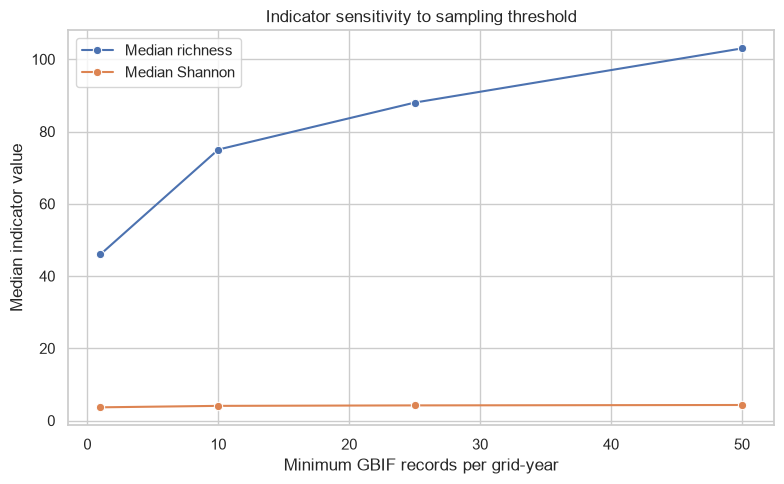

In [ ]:
indicator_columns = [
    "total_occurrences", "species_richness", "shannon_diversity",
    "simpson_diversity", "pielou_evenness"
]
effort_correlations = grid_year[indicator_columns].rank(method="average").corr().loc[
    ["total_occurrences"], indicator_columns[1:]
].rename(index={"total_occurrences": "spearman_with_occurrence_effort"})

threshold_rows = []
for threshold in [1, 10, 25, 50]:
    subset = grid_year[grid_year["total_occurrences"] >= threshold]
    threshold_rows.append({
        "minimum_occurrences": threshold,
        "grid_years_retained": len(subset),
        "retained_pct": len(subset) / len(grid_year) * 100,
        "median_richness": subset["species_richness"].median(),
        "median_shannon": subset["shannon_diversity"].median(),
        "median_simpson": subset["simpson_diversity"].median(),
        "median_evenness": subset["pielou_evenness"].median(),
    })
threshold_sensitivity = pd.DataFrame(threshold_rows)

print("Rank correlations with observation effort:")
display(effort_correlations)
print("Sensitivity to the minimum sampling threshold:")
display(threshold_sensitivity)

plt.figure(figsize=(8, 5))
sns.lineplot(threshold_sensitivity, x="minimum_occurrences", y="median_richness", marker="o", label="Median richness")
sns.lineplot(threshold_sensitivity, x="minimum_occurrences", y="median_shannon", marker="o", label="Median Shannon")
plt.title("Indicator sensitivity to sampling threshold")
plt.xlabel("Minimum GBIF records per grid-year")
plt.ylabel("Median indicator value")
plt.tight_layout()
plt.show()

## 9. Export analytical tables

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_paths = {
    "grid_year_indicators": OUTPUT_DIR / "grid_year_biodiversity_indicators.parquet",
    "annual_richness": OUTPUT_DIR / "annual_species_richness.csv",
    "grid_richness": OUTPUT_DIR / "grid_species_richness.csv",
    "species_frequency": OUTPUT_DIR / "species_frequency.csv",
    "taxonomic_composition": OUTPUT_DIR / "taxonomic_composition.csv",
    "indicator_validation": OUTPUT_DIR / "indicator_validation.csv",
    "threshold_sensitivity": OUTPUT_DIR / "threshold_sensitivity.csv",
}

grid_year.to_parquet(output_paths["grid_year_indicators"], index=False)
annual_richness.to_csv(output_paths["annual_richness"], index=False)
grid_richness.to_csv(output_paths["grid_richness"], index=False)
species_frequency.to_csv(output_paths["species_frequency"], index=False)
taxonomic_composition.to_csv(output_paths["taxonomic_composition"], index=False)
validation_results.to_csv(output_paths["indicator_validation"], index=False)
threshold_sensitivity.to_csv(output_paths["threshold_sensitivity"], index=False)

print("Created analytical outputs:")
for name, path in output_paths.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Created analytical outputs:
- grid_year_indicators: data\processed\analytics\grid_year_biodiversity_indicators.parquet
- annual_richness: data\processed\analytics\annual_species_richness.csv
- grid_richness: data\processed\analytics\grid_species_richness.csv
- species_frequency: data\processed\analytics\species_frequency.csv
- taxonomic_composition: data\processed\analytics\taxonomic_composition.csv
- indicator_validation: data\processed\analytics\indicator_validation.csv
- threshold_sensitivity: data\processed\analytics\threshold_sensitivity.csv


## 10. Interpretation checkpoint

- Richness and diversity are observation-based indicators and should be compared only after applying sampling-quality filters.
- A high record count can reflect observer activity rather than ecological abundance.
- The Aves-dominated source composition means all-taxa indicators largely reflect bird reporting. Class-specific analyses should be preferred where possible.
- The coarse India bounding-box screen catches obvious spatial errors but does not replace polygon validation.
- External validation against standardized surveys or authoritative checklists remains necessary before conservation decisions.

In [ ]:
print("===== PERSON 1 ANALYTICS COMPLETE =====")
print(f"Analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")
print(f"Species analysed: {analysis['specieskey'].nunique():,}")
print(f"Grid cells analysed: {analysis['eqdcellcode'].nunique():,}")
print(f"Grid x Year indicators: {len(grid_year):,}")
print(f"Validation errors: {(validation_results['status'] == 'ERROR').sum()}")
print(f"Validation warnings: {(validation_results['status'] == 'WARN').sum()}")

===== PERSON 1 ANALYTICS COMPLETE =====
Analysis period: 2015-2024
Species analysed: 11,474
Grid cells analysed: 6,625
Grid x Year indicators: 36,078
Validation errors: 0
Validation warnings: 1
